# PoDP Filtering for ML

> ⚠️ **SUPERSEDED for dataset counts (2026-09-04).** This notebook documents
> the *exploration and filtering logic*, and its rules are still the reference
> for how the funnel works. But the authoritative counts and CSVs are now
> produced by `scripts/podp/build_curated_datasets.py`:
>
> - **curated ground truth links** (aka curated experimentally-validated
>   links): **64** links / 21 projects / 34 distinct MIBiG BGCs, backed by
>   **53** data file pairs over 34 isolates.
> - **curated paired dataset** (aka curated genome-metabolome paired dataset):
>   **3,585** data file pairs / 65 studies / 1,039 isolates.
>
> Two bugs were fixed here on 2026-09-04: the genome-accession keys (cells 3
> and 15 looked up `GenBank_ID`/`RefSeq_ID`/`ENA_ID`, but PoDP writes
> `*_accession` — this undercounted retrievable genomes ~2.5x, giving 1,364
> instead of 3,435) and the hardcoded Colab paths (cells 1/3/10). The CSVs
> this notebook writes are NOT the curated datasets; two of its earlier
> outputs are retired under `results/podp/archive/`.


In [ ]:
import pandas as pd
import glob
import json

# Define the path to the directory containing the JSON files
json_files_path = '../../data/raw/podp_database/*.json'

# Get a list of all JSON files in the directory
json_files = glob.glob(json_files_path)

# Initialize an empty list to store data from each JSON file
all_data = []

# Loop through each JSON file, load its content, and append to the list
for file_path in json_files:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            all_data.append(data)
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from {file_path}: {e}")
    except Exception as e:
        print(f"An error occurred while reading {file_path}: {e}")

# Convert the list of dictionaries to a pandas DataFrame
if all_data:
    df = pd.DataFrame(all_data)
    print("Successfully loaded and combined JSON files into a DataFrame.")
    print("\nFirst 5 rows of the dataset:")
    print(df.head())
    print("\nShape of the dataset (rows, columns):")
    print(df.shape)
    print("\nInformation about the dataset (data types, non-null values):")
    df.info()
else:
    print("No data was loaded or combined. Please check the JSON files and path.")

Successfully loaded and combined JSON files into a DataFrame.

First 5 rows of the dataset:
  version                                           personal  \
0       3  {'submitter_name': 'Kelly Weldon', 'submitter_...   
1       3  {'submitter_name': 'Carmen Saenz', 'submitter_...   
2       3  {'submitter_name': 'Louis Felix Nothias', 'sub...   
3       3  {'submitter_name': 'Andrew McAvoy', 'submitter...   
4       3  {'submitter_name': 'Doug Sweeney', 'submitter_...   

                                        metabolomics  \
0  {'project': {'GNPSMassIVE_ID': 'MSV000083302',...   
1  {'project': {'GNPSMassIVE_ID': 'MSV000083734',...   
2  {'project': {'GNPSMassIVE_ID': 'MSV000083835',...   
3  {'project': {'GNPSMassIVE_ID': 'MSV000084945',...   
4  {'project': {'GNPSMassIVE_ID': 'MSV000085180',...   

                                        experimental  \
0  {'sample_preparation': [{'medium_details': {'m...   
1  {'sample_preparation': [{'medium_details': {'m...   
2  {'sample_prepar

## Filtering BGC-MS2 Links
(PODP Data Retrieval Blueprint for Machine Learning Validation)

This section processes the `BGC_MS2_links` entries from the original database to identify valid BGC-MS2 pairs for further analysis. A BGC-MS2 pair is considered valid if it explicitly links a Biosynthetic Gene Cluster (BGC) via a MIBiG ID and a Mass Spectrometry (MS2) spectrum via a GNPS MassIVE ID.

```                                  [ PODP DATA LINK ]
                                          │
                  ┌───────────────────────┴───────────────────────┐
                  ▼                                               ▼
     🧬 GENOMIC VECTOR (BGC .gbk)                   🧪 METABOLOMIC VECTOR (MS2 Spectra)
                  │                                               │
   ┌──────────────┴──────────────┐                 ┌──────────────┴──────────────┐
   ▼                             ▼                 ▼                             ▼
[MIBiG ID]               [NCBI Accession]    [Direct MS2 URL]              [MassIVE ID]
   │                             │                 │                             │
   ▼                             ▼                 ▼                             ▼
Direct API                antiSMASH DB /     Direct Download               FTP Crawl /
Download                  Biopython Download                                 GNPS API

```

**A pair is "ML-Ready" if it passes both downstream validations:**
```df['Genomic_Resolved'] = df['mibig_id'].notna() | df['ncbi_assembly_id'].notna()
df['Spectral_Resolved'] = df['ms2_url'].notna() | df['massive_id'].notna() | df['gnps_task_id'].notna()

df['ML_Ready_Train_Data'] = df['Genomic_Resolved'] & df['Spectral_Resolved']```


In [56]:
import pandas as pd
import json
import glob
import re # Import regex for parsing URLs
import matplotlib.pyplot as plt
import seaborn as sns # For aesthetics

# Code to load df from JSON files, copied from cell kww0KDs7dZSq
# This ensures the dataframe 'df' is always available when this cell runs.
json_files_path = '../../data/raw/podp_database/*.json'
json_files = glob.glob(json_files_path)
all_data = []
for file_path in json_files:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            all_data.append(data)
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from {file_path}: {e}")
    except Exception as e:
        print(f"An error occurred while reading {file_path}: {e}")

if all_data:
    df = pd.DataFrame(all_data)
    print("Successfully loaded and combined JSON files into a DataFrame.")
else:
    print("No data was loaded or combined. Please check the JSON files and path.")

# Define the proof types as specified by the user
PROOF_TYPES = [
    "Experimentally validated with knockouts, heterologous expression, or other gene cluster manipulation",
    "Bioinformatically inferred through comparative analysis with another experimentally defined gene cluster",
    "Experimentally validated with NMR and/or detailed MS/MS analysis",
    "Evidence as indicated in MIBiG"
]

# List to store all processed BGC-MS2 links with detailed information
processed_bgc_ms2_links_summary = []

for study_idx, study_row in df.iterrows():
    study_identifier = f"Study_{study_idx}"

    # Extract study-level metabolomics project ID for Rule 3
    study_gnps_massive_id = study_row.get('metabolomics', {}).get('project', {}).get('GNPSMassIVE_ID')

    # Create a lookup for genome accessions within the current study for Rule 2
    genome_accession_lookup = {}
    if isinstance(study_row.get('genomes'), list):
        for genome_entry in study_row['genomes']:
            genome_label = genome_entry.get('genome_label')
            genome_id_info = genome_entry.get('genome_ID', {})
            if genome_label:
                # PoDP writes *_accession names, not *_ID. Reading the *_ID
                # spellings made every GenBank/RefSeq/ENA accession resolve to
                # None (same bug as cell 15). Internal dict keys are left as
                # *_ID so the logic below is unchanged.
                genome_accession_lookup[genome_label] = {
                    'GenBank_ID': genome_id_info.get('GenBank_accession'),
                    'RefSeq_ID': genome_id_info.get('RefSeq_accession'),
                    'ENA_ID': genome_id_info.get('ENA_NCBI_accession'),
                    'JGI_ID': (genome_id_info.get('JGI_Genome_ID')
                               or genome_id_info.get('JGI_IMG_genome_ID')
                               or genome_id_info.get('JGI_ID')),
                }

    if isinstance(study_row.get('BGC_MS2_links'), list) and study_row['BGC_MS2_links']:
        for link_entry in study_row['BGC_MS2_links']:
            # Initialize all flags for the current link
            strict_dual_accession_pass = False
            genome_sequence_retrievable = False
            ms2_data_retrievable = False
            dataset_tier = "Untiered"

            # Extract primary IDs from the link entry
            mibig_id = link_entry.get('BGC_ID', {}).get('MIBiG_number')
            # Normalize mibig_id if it's the placeholder string
            if mibig_id == 'MIBiG number of a similar BGC':
                mibig_id = None

            ncbi_genome_accession_from_link = link_entry.get('BGC_ID', {}).get('ncbi_genome_accession')
            ms2_url = link_entry.get('MS2_URL')
            link_genome_label = link_entry.get('BGC_ID', {}).get('genome_label') # Attempt to find genome_label in BGC_ID
            if not link_genome_label:
                 link_genome_label = link_entry.get('genome_label') # Or directly in link_entry

            # --- Rule 1: Dual Input Ground Truth Check ---
            genomic_anchor_found = False
            if mibig_id:
                genomic_anchor_found = True
            elif ncbi_genome_accession_from_link:
                genomic_anchor_found = True
            # Check if an identified genome label for this BGC link has any public accession in the study's genome list
            elif link_genome_label and genome_accession_lookup.get(link_genome_label):
                genome_details_for_link = genome_accession_lookup[link_genome_label]
                if genome_details_for_link.get('GenBank_ID') or \
                   genome_details_for_link.get('RefSeq_ID') or \
                   genome_details_for_link.get('ENA_ID') or \
                   genome_details_for_link.get('JGI_ID'):
                    genomic_anchor_found = True


            metabolomic_anchor_found = False
            if ms2_url and ms2_url.strip(): # Direct URL indicates an anchor
                metabolomic_anchor_found = True
            elif study_gnps_massive_id and study_gnps_massive_id.strip(): # Study-level MassIVE ID
                metabolomic_anchor_found = True

            strict_dual_accession_pass = genomic_anchor_found and metabolomic_anchor_found

            # --- Rule 2: Genomic Sequence Traceability (Input Vector A) ---
            if mibig_id: # Conditional Path A (Direct MIBiG)
                genome_sequence_retrievable = True
            elif ncbi_genome_accession_from_link: # Conditional Path B (Whole Genome, direct accession in link)
                genome_sequence_retrievable = True
            # Conditional Path B (Whole Genome, from parent study metadata)
            elif link_genome_label and genome_accession_lookup.get(link_genome_label):
                 genome_details_for_link = genome_accession_lookup[link_genome_label]
                 if genome_details_for_link.get('GenBank_ID') or \
                    genome_details_for_link.get('RefSeq_ID') or \
                    genome_details_for_link.get('ENA_ID') or \
                    genome_details_for_link.get('JGI_ID'):
                     genome_sequence_retrievable = True

            # --- Rule 3: Raw Spectral Data Traceability (Input Vector B) ---
            if ms2_url and ms2_url.strip(): # Conditional Path A (Direct URL)
                ms2_data_retrievable = True
                # Also check for GNPS task_id within the URL
                if not re.search(r'task=([a-zA-Z0-9-]+)', ms2_url):
                    # If direct URL is present but no task ID, check for MassIVE in URL
                    if not re.search(r'MSV[0-9]{9}', ms2_url):
                        # If it's a generic URL, assume retrievable if non-empty
                        pass
            elif study_gnps_massive_id and study_gnps_massive_id.strip(): # Conditional Path B (Dataset FTP)
                ms2_data_retrievable = True

            # Additional check for GNPS task ID if not already covered by MS2_URL or study_gnps_massive_id
            if not ms2_data_retrievable and ms2_url and ms2_url.strip():
                gnps_task_match = re.search(r'task=([a-zA-Z0-9-]+)', ms2_url)
                if gnps_task_match: # Conditional Path C (GNPS Network Task)
                    ms2_data_retrievable = True

            # --- Rule 4: Data Quality & Proof Level Stratification ---
            gold_standard_proof = False
            silver_standard_proof = False
            matched_proof_types = []

            verification_list = link_entry.get('verification', [])
            if isinstance(verification_list, list):
                for proof in verification_list:
                    if proof == PROOF_TYPES[0] or proof == PROOF_TYPES[2]: # Type 1 or Type 3
                        gold_standard_proof = True
                    elif proof == PROOF_TYPES[1]: # Type 2
                        silver_standard_proof = True
                    matched_proof_types.append(proof)

            # Modified tiering logic to combine Gold and Silver into 'Validated'
            if gold_standard_proof or silver_standard_proof:
                dataset_tier = "Validated"
            else:
                dataset_tier = "Untiered"

            # Append the processed link details
            processed_bgc_ms2_links_summary.append({
                'study_identifier': study_identifier,
                'mibig_id': mibig_id,
                'ncbi_genome_accession_from_link': ncbi_genome_accession_from_link,
                'ms2_url': ms2_url,
                'study_gnps_massive_id': study_gnps_massive_id,
                'strict_dual_accession_pass': strict_dual_accession_pass,
                'genome_sequence_retrievable': genome_sequence_retrievable,
                'ms2_data_retrievable': ms2_data_retrievable,
                'dataset_tier': dataset_tier,
                'all_proof_types': "; ".join(matched_proof_types) if matched_proof_types else "None"
            })

# Convert to DataFrame for easier inspection
bgc_ms2_links_processed_df = pd.DataFrame(processed_bgc_ms2_links_summary)

# --- Generate the requested Summary Table ---

# Calculate counts for the summary table
total_links_considered = len(bgc_ms2_links_processed_df)
strict_dual_accession_pass_count = bgc_ms2_links_processed_df['strict_dual_accession_pass'].sum()
genomic_resolvable_count = bgc_ms2_links_processed_df['genome_sequence_retrievable'].sum()
spectral_resolvable_count = bgc_ms2_links_processed_df['ms2_data_retrievable'].sum()

# Filter for ML-Ready links (all three main criteria met)
ml_model_viable_df = bgc_ms2_links_processed_df[
    (bgc_ms2_links_processed_df['strict_dual_accession_pass'] == True) &
    (bgc_ms2_links_processed_df['genome_sequence_retrievable'] == True) &
    (bgc_ms2_links_processed_df['ms2_data_retrievable'] == True)
].copy()

# New count for 'ML-Ready Validated Pairs'
ml_ready_validated_count = ml_model_viable_df[ml_model_viable_df['dataset_tier'] == 'Validated'].shape[0]

# Prepare summary table for display
summary_data = {
    "Category Filter": [
        "Total Links Considered",
        "Strict Dual-Accession Pass",
        "Genomic Resolvable",
        "Spectral Resolvable",
        "ML-Ready Validated Pairs" # Changed from 'ML-Ready Gold Tier'
    ],
    "Description": [
        "Absolute total in dataset",
        "Has both a genomic anchor and a metabolomic study anchor",
        "Has MIBiG ID or NCBI Genome reference to parse sequence. These IDs (e.g., MIBiG number, GenBank_ID, RefSeq_ID, ENA_ID) allow for programmatic retrieval of .gbk (GenBank) format files using tools like the MIBiG API or NCBI Entrez. These .gbk files contain the raw genome sequence information for model input.", # Added explanation
        "Has direct MS2 URL or parent dataset repository ID. Direct URLs to .mzML/.mzXML files can be downloaded. For MassIVE IDs (MSV...), the data can be accessed via FTP or their API. For GNPS task IDs, consensus MS2 spectra are programmatically available. These files provide the raw MS2 spectral data for model input.", # Added explanation
        "Both genomic and spectral inputs are resolvable AND have experimental (Proof 1 or 3) or bioinformatic (Proof 2) evidence. These pairs constitute the dataset for ML model validation." # Updated description
    ],
    "Count": [
        total_links_considered,
        int(strict_dual_accession_pass_count),
        int(genomic_resolvable_count),
        int(spectral_resolvable_count),
        int(ml_ready_validated_count) # Updated to new combined count
    ]
}

summary_table = pd.DataFrame(summary_data)
display(summary_table)

print("\n--- First 5 ML-Ready Links (if any) ---")
if not ml_model_viable_df.empty:
    display(ml_model_viable_df.head())
else:
    print("No ML-Ready links found based on the defined criteria.")


Successfully loaded and combined JSON files into a DataFrame.


,Category Filter,Description,Count
0,Total Links Considered,Absolute total in dataset,115
1,Strict Dual-Accession Pass,Has both a genomic anchor and a metabolomic st...,82
2,Genomic Resolvable,Has MIBiG ID or NCBI Genome reference to parse...,82
3,Spectral Resolvable,Has direct MS2 URL or parent dataset repositor...,115
4,ML-Ready Validated Pairs,Both genomic and spectral inputs are resolvabl...,77



--- First 5 ML-Ready Links (if any) ---


,study_identifier,mibig_id,ncbi_genome_accession_from_link,ms2_url,study_gnps_massive_id,strict_dual_accession_pass,genome_sequence_retrievable,ms2_data_retrievable,dataset_tier,all_proof_types
0,Study_2,BGC0000845,None,ftp://massive.ucsd.edu/MSV000083835/peak/MeOH_...,MSV000083835,True,True,True,Validated,"Experimentally validated with knockouts, heter..."
1,Study_2,BGC0000319,None,ftp://massive.ucsd.edu/MSV000083835/peak/MeOH_...,MSV000083835,True,True,True,Validated,"Experimentally validated with knockouts, heter..."
2,Study_2,BGC0000880,None,ftp://massive.ucsd.edu/MSV000083835/peak/MeOH_...,MSV000083835,True,True,True,Validated,Bioinformatically inferred through comparative...
3,Study_2,BGC0000880,None,ftp://massive.ucsd.edu/MSV000083835/peak/MeOH_...,MSV000083835,True,True,True,Validated,Bioinformatically inferred through comparative...
4,Study_2,BGC0000880,None,ftp://massive.ucsd.edu/MSV000083835/peak/MeOH_...,MSV000083835,True,True,True,Validated,Bioinformatically inferred through comparative...


In [57]:
# Save the 77 validated pairs to a CSV file
final_ml_ready_df = ml_model_viable_df[ml_model_viable_df['dataset_tier'] == 'Validated'].copy()
output_bgc_ms2_csv_path = 'podp_bgc_ms2_pairs.csv'
final_ml_ready_df.to_csv(output_bgc_ms2_csv_path, index=False)
print(f"\nML-Ready Validated BGC-MS2 links ({len(final_ml_ready_df)} pairs) saved to {output_bgc_ms2_csv_path}")


ML-Ready Validated BGC-MS2 links (77 pairs) saved to podp_bgc_ms2_pairs.csv



--- BGC-MS2 Link Filtering Summary ---


/tmp/ipykernel_1763/2128977281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category Filter", y="Count", data=summary_table, palette="viridis", ax=ax)
/tmp/ipykernel_1763/2128977281.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


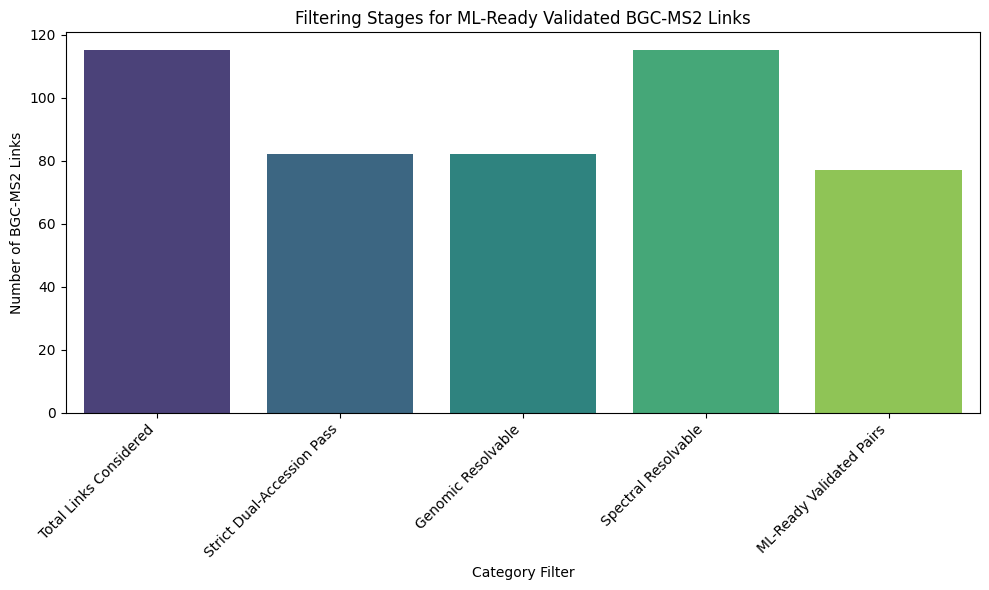

In [58]:
# Create a figure summarizing BGC-MS2 filtering
plt.close('all') # Close previous figures
print("\n--- BGC-MS2 Link Filtering Summary ---")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x="Category Filter", y="Count", data=summary_table, palette="viridis", ax=ax)
ax.set_ylabel("Number of BGC-MS2 Links")
ax.set_title("Filtering Stages for ML-Ready Validated BGC-MS2 Links")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 🧬 Genomic Vector Retrieval (BGC Sequence Files)
PODP rarely mirrors sequence files directly. Instead, it provides database hooks. Use the following logic blocks to systematically pull down the .gbk (GenBank) files.
#### Pathway A: Direct MIBiG Retrieval

* Trigger condition: The entry contains a populated, valid mibig_id (e.g., BGC0000845).
* Source Repository: [MIBiG (Minimum Information about a Biosynthetic Gene Cluster)](https://mibig.secondarymetabolites.org/)
* Implementation Rule: Bypasses any external genome pipeline. Use a simple text stream or file download over HTTPS targeting MIBiG's stable file layout.
* Retrieval Formula:
$$\text{URL} = \texttt{"https://secondarymetabolites.org"} + \text{mibig\_id} + \texttt{"/"} + \text{mibig\_id} + \texttt{".gbk"}$$

#### Pathway B: Whole-Genome Extraction (Fallback)

* Trigger condition: mibig_id is absent, but an NCBI reference identifier or Assembly Accexsion (e.g., GCA_xxxxxxxx.x, GCF_xxxxxxxx.x, or a nucleotide identifier like NZ_xxxxxx) is identified within the study metadata.
* Source Repository: [NCBI Assembly / Nucleotide Databases](https://www.ncbi.nlm.nih.gov/) and [antiSMASH Database](https://antismash-db.secondarymetabolites.org/)
* Implementation Rule:
1. Query the antiSMASH DB API directly using the NCBI assembly string to see if the genome has pre-computed clusters available for download.
   2. If pre-computed clusters do not exist, use NCBI Entrez Direct or Biopython.Entrez to download the entire multi-FASTA/GenBank chromosome or scaffold file. Subsequently, run a local command-line instance of antiSMASH to isolate and crop out the specific core coordination boundaries of the BGC.

### 🧪 Metabolomic Vector Retrieval (Mass Spectrometry Files)
Raw mass spectrometry data can exist as standalone files or embedded within massive global datasets. Use these rules to sweep for spectral data.
#### Pathway A: Direct File Targets

* Trigger condition: ms2_data_accessible is True and MS2_URL points directly to an active file.
* Source Repository: Hosted web domains (commonly GNPS, MassIVE FTP, or Zenodo).
* Implementation Rule: Use a direct HTTP GET request to stream the open-source spectrum file (.mzXML, .mzML, or .mgf).

#### Pathway B: MassIVE FTP Crawling

* Trigger condition: The MS2_URL field is absent or malformed, but the study_identifier or secondary tracking fields contain a MassIVE reference code (e.g., MSV000084000).
* Source Repository: [UCSD MassIVE (Mass Spectrometry Interactive Virtual Environment)](https://massive.ucsd.edu/)
* Implementation Rule: Raw files are structurally stored on public FTP hubs. Instead of searching a broken direct link, navigate the corresponding study dataset via Python's ftplib.
* Retrieval Formula:
$$\text{FTP Path} = \texttt{"ftp://massive.ucsd.edu/"} + \text{MassIVE\_ID} + \texttt{"/spectrum/"}$$
(Note: Peak-picked and converted spectra are alternatively located in the /ccms_peak/ directories if the raw vendor files inside the peak spectrum directories require format conversion).

#### Pathway C: GNPS Molecular Networking Tasks

* Trigger condition: The dataset points to a processed GNPS task identifier (e.g., an alphanumeric string in a URL structure mapping to gnps.ucsd.edu).
* Source Repository: [GNPS (Global Natural Products Social Molecular Networking)](https://gnps.ucsd.edu/)
* Implementation Rule: If raw individual instrument spectra are unresolvable, the molecular network task endpoint provides structured consensus spectra files. Programmatically download the compiled .mgf cluster spectra using the GNPS API cluster extraction parameters:
$$\text{URL} = \texttt{"https://ucsd.edu"} + \text{task\_id} + \texttt{"&block=main&file=METABOLOMICS-SNETS-V2-XXX/clusterwms2.mgf"}$$


## Filtering Pairs of Genome-Metabolome Files

In [ ]:
import pandas as pd
import os
from urllib.parse import urlparse

unique_genome_types = set()
unique_sequencing_types = set()
unique_metabolomics_file_types = set()
example_genome_metabolome_link = None

for study_idx, study_row in df.iterrows():
    # Collect genome types and sequencing types
    if isinstance(study_row['genomes'], list) and study_row['genomes']:
        for genome_entry in study_row['genomes']:
            genome_id_info = genome_entry.get('genome_ID', {})
            genome_type = genome_id_info.get('genome_type')
            sequencing_type = genome_id_info.get('sequencing_type')
            if genome_type: unique_genome_types.add(genome_type)
            if sequencing_type: unique_sequencing_types.add(sequencing_type)

    # Collect metabolomics file types and capture an example link
    if isinstance(study_row['genome_metabolome_links'], list) and study_row['genome_metabolome_links']:
        if example_genome_metabolome_link is None:
            example_genome_metabolome_link = study_row['genome_metabolome_links'][0]

        for link_entry in study_row['genome_metabolome_links']:
            metabolomics_file_full_url = link_entry.get('metabolomics_file')
            if metabolomics_file_full_url:
                path = urlparse(metabolomics_file_full_url).path
                file_name_with_ext = os.path.basename(path)
                if '.' in file_name_with_ext:
                    unique_metabolomics_file_types.add(file_name_with_ext.split('.')[-1].lower())

print("\n--- Unique Genome Types Found ---")
print(sorted(list(unique_genome_types)))

print("\n--- Unique Sequencing Types Found ---")
print(sorted(list(unique_sequencing_types)))

print("\n--- Unique Metabolomics File Types Found (from URLs) ---")
print(sorted(list(unique_metabolomics_file_types)))

print("\n--- Example of a genome_metabolome_links Entry ---")
if example_genome_metabolome_link:
    import json
    print(json.dumps(example_genome_metabolome_link, indent=2))
else:
    print("No example genome_metabolome_links entry found.")


--- Unique Genome Types Found ---
['genome', 'metagenome', 'metagenome-assembled genome']

--- Unique Sequencing Types Found ---
[]

--- Unique Metabolomics File Types Found (from URLs) ---
['mgf', 'mzml', 'mzxml', 'mzxmll']

--- Example of a genome_metabolome_links Entry ---
{
  "genome_label": "ERS4356233",
  "metabolomics_file": "ftp://massive.ucsd.edu/MSV000083302/peak/mzxml/S96_RE2_01_40404.mzXML",
  "sample_preparation_label": "metagenomic_mouse_fecal",
  "extraction_method_label": "SeedGrant_Extraction",
  "instrumentation_method_label": "Seed Grant TOF"
}


In [ ]:
import pandas as pd
import os
from urllib.parse import urlparse

# Ensure df is available (assuming it was loaded in the previous cell)
# If running this cell independently, uncomment and run the previous loading logic or ensure df is in the kernel state.
# import glob
# import json
# json_files_path = '../../data/raw/podp_database/*.json'
# json_files = glob.glob(json_files_path)
# all_data = []
# for file_path in json_files:
#     try:
#         with open(file_path, 'r') as f:
#             data = json.load(f)
#             all_data.append(data)
#     except Exception as e:
#         print(f"Error with {file_path}: {e}")
# if all_data:
#     df = pd.DataFrame(all_data)


# List to store all processed genome-metabolome links
processed_links_summary = []

for study_idx, study_row in df.iterrows():
    study_identifier = f"Study_{study_idx}" # A unique identifier for the study

    # Create a quick lookup for genome types and sequencing types within the current study
    genome_details_map = {}
    if isinstance(study_row['genomes'], list) and study_row['genomes']:
        for genome_entry in study_row['genomes']:
            genome_label = genome_entry.get('genome_label')
            genome_id_info = genome_entry.get('genome_ID', {})
            genome_type = genome_id_info.get('genome_type')
            sequencing_type = genome_id_info.get('sequencing_type')
            # Store relevant details for later checks
            genome_details_map[genome_label] = {
                'genome_type': genome_type,
                'sequencing_type': sequencing_type,
            }

    # Iterate through each genome-metabolome link in the current study
    if isinstance(study_row['genome_metabolome_links'], list) and study_row['genome_metabolome_links']:
        for link_entry in study_row['genome_metabolome_links']:
            link_status = 'KEPT'
            discard_reasons = []

            genome_label = link_entry.get('genome_label')

            # --- Corrected parsing for Metabolome details ---
            metabolomics_file_full_url = link_entry.get('metabolomics_file')
            metabolomics_file_path = metabolomics_file_full_url # Use the full URL as the file path
            metabolomics_file_type = None
            if metabolomics_file_full_url:
                # Extract file extension from the URL
                path = urlparse(metabolomics_file_full_url).path
                file_name_with_ext = os.path.basename(path)
                if '.' in file_name_with_ext:
                    metabolomics_file_type = file_name_with_ext.split('.')[-1].lower() # Convert to lowercase for consistent checking

            # For 'metabolomics_host_id', assuming the linked genome_label implies the host
            # within the context of this specific genome-metabolome link.
            metabolomics_host_id = genome_label # Using genome_label as the host identifier for the linked metabolome

            # --- 1. Genome Type Filtering (Relaxed) ---
            current_genome_type = 'N/A'
            current_sequencing_type = 'N/A'

            genome_details = genome_details_map.get(genome_label)
            if not genome_details:
                link_status = 'DISCARDED'
                discard_reasons.append(f"Genome '{genome_label}' details not found in study's genome list.")
            else:
                current_genome_type = genome_details.get('genome_type')
                current_sequencing_type = genome_details.get('sequencing_type') # Keep this for output, but not for filtering below

                if current_genome_type == 'metagenome_assembly':
                    link_status = 'DISCARDED'
                    discard_reasons.append(f"Genome '{genome_label}' is 'meta-genome assembly'.")
                elif current_genome_type == 'metagenome':
                    link_status = 'DISCARDED'
                    discard_reasons.append(f"Genome '{genome_label}' is a 'metagenome'.")
                # Relaxed: Only discard if not 'genome' type. No sequencing type check.
                elif current_genome_type != 'genome':
                    link_status = 'DISCARDED'
                    discard_reasons.append(f"Genome '{genome_label}' has unsupported type ('{current_genome_type}'). Only 'genome' type is allowed.")

            # --- 2. Metabolome File Type Filtering (Relaxed) ---
            # Now only include 'mzml' and 'mzxml'
            if metabolomics_file_type not in ['mzml', 'mzxml']:
                link_status = 'DISCARDED'
                discard_reasons.append(f"Metabolome file type '{metabolomics_file_type}' is not 'mzML' or 'mzXML'.")

            # --- 3. Metabolome Host Attribution Filtering ---
            if not metabolomics_host_id:
                link_status = 'DISCARDED'
                discard_reasons.append("Metabolome data not attributed to a single host (missing 'host_id').")

            # --- 4. Same Source/Experiment Check ---
            # The presence of the link within the study is taken to mean they originate from the same experiment/study context.

            processed_links_summary.append({
                'study_identifier': study_identifier,
                'genome_label': genome_label,
                'metabolomics_file_path': metabolomics_file_path,
                'metabolomics_file_type': metabolomics_file_type,
                'metabolomics_host_id': metabolomics_host_id,
                'genome_type': current_genome_type,
                'genome_sequencing_type': current_sequencing_type, # Still include for context in output
                'sample_preparation_label': link_entry.get('sample_preparation_label'),
                'extraction_method_label': link_entry.get('extraction_method_label'),
                'instrumentation_method_label': link_entry.get('instrumentation_method_label'),
                'status': link_status,
                'discard_reasons': "; ".join(discard_reasons) if discard_reasons else "N/A"
            })

# Convert to DataFrame for easier inspection and counting
final_links_df = pd.DataFrame(processed_links_summary)

# Count unique kept pairs
kept_pairs = final_links_df[final_links_df['status'] == 'KEPT'].drop_duplicates(subset=['genome_label', 'metabolomics_file_path'])
discarded_pairs = final_links_df[final_links_df['status'] == 'DISCARDED']

print(f"Total genome-metabolome links processed: {len(final_links_df)}")
print(f"Number of unique KEPT genome-metabolome pairs: {len(kept_pairs)}")
print(f"Number of DISCARDED genome-metabolome pairs: {len(discarded_pairs)}")

print("\n--- Breakdown of DISCARDED Pairs by Reason ---")
if not discarded_pairs.empty:
    # Group by discard reasons and count occurrences
    reason_counts = discarded_pairs.groupby('discard_reasons').size().reset_index(name='count')
    # Sort by count in descending order for better readability
    reason_counts = reason_counts.sort_values(by='count', ascending=False)
    for _, row in reason_counts.iterrows():
        print(f"  - {row['discard_reasons']}: {row['count']}")
else:
    print("No pairs were discarded.")

print("\n--- KEPT Genome-Metabolome Pairs (Unique) ---")
if not kept_pairs.empty:
    # Limiting the output of individual kept pairs to avoid excessive verbosity
    print("Displaying first 20 kept pairs as an example:")
    for _, row in kept_pairs.head(20).iterrows():
        print(f"Study: {row['study_identifier']}, Genome: {row['genome_label']} (Type: {row['genome_type']}, Seq: {row['genome_sequencing_type']}), Metabolome: {row['metabolomics_file_path']} (Type: {row['metabolomics_file_type']}, Host: {row['metabolomics_host_id']}, Sample Prep: {row['sample_preparation_label']}, Extr: {row['extraction_method_label']}, Instr: {row['instrumentation_method_label']})")
    if len(kept_pairs) > 20:
        print(f"... {len(kept_pairs) - 20} more kept pairs not shown.")
else:
    print("No pairs were kept based on the specified criteria.")

print("\n--- DISCARDED Genome-Metabolome Pairs (with reasons) ---")
if not discarded_pairs.empty:
    # Limiting the output of individual discarded pairs to avoid excessive verbosity
    print("Displaying first 20 discarded pairs as an example:")
    for _, row in discarded_pairs.head(20).iterrows():
        print(f"Study: {row['study_identifier']}, Genome: {row['genome_label']}, Metabolome: {row['metabolomics_file_path']}, Reason: {row['discard_reasons']}")
    if len(discarded_pairs) > 20:
        print(f"... {len(discarded_pairs) - 20} more discarded pairs not shown.")
else:
    print("No pairs were discarded.")

Total genome-metabolome links processed: 4966
Number of unique KEPT genome-metabolome pairs: 3454
Number of DISCARDED genome-metabolome pairs: 1488

--- Breakdown of DISCARDED Pairs by Reason ---
  - Metabolome file type 'None' is not 'mzML' or 'mzXML'.: 46
  - Genome '‘Candidatus Entotheonella factor’' has unsupported type ('metagenome-assembled genome'). Only 'genome' type is allowed.: 15
  - Genome 'Okeania sp. SIO1H4' has unsupported type ('metagenome-assembled genome'). Only 'genome' type is allowed.: 10
  - Genome 'Symploca sp. SIO3C6' has unsupported type ('metagenome-assembled genome'). Only 'genome' type is allowed.: 10
  - Genome 'Moorea sp. SIO3A5' has unsupported type ('metagenome-assembled genome'). Only 'genome' type is allowed.: 10
  - Genome 'Microcoleus sp. SIO2G3' has unsupported type ('metagenome-assembled genome'). Only 'genome' type is allowed.: 10
  - Genome 'Okeania sp. SIO2F4' has unsupported type ('metagenome-assembled genome'). Only 'genome' type is allowed.: 

In [ ]:
# Further filter kept_pairs to ensure 'same experiment' criteria are met
# This means all three experimental labels must be present (not null)

initial_kept_count = len(kept_pairs)

filtered_kept_pairs = kept_pairs.dropna(subset=[
    'sample_preparation_label',
    'extraction_method_label',
    'instrumentation_method_label'
])

final_kept_count = len(filtered_kept_pairs)
discarded_by_experiment_criteria = initial_kept_count - final_kept_count

print(f"\n--- Filtering for 'Same Experiment' Criteria ---")
print(f"Initial unique kept pairs: {initial_kept_count}")
print(f"Pairs discarded due to missing experimental labels: {discarded_by_experiment_criteria}")
print(f"Final unique kept pairs after 'same experiment' filtering: {final_kept_count}")

print("\n--- KEPT Genome-Metabolome Pairs (after 'Same Experiment' filter) ---")
if not filtered_kept_pairs.empty:
    print("Displaying first 20 filtered kept pairs as an example:")
    for _, row in filtered_kept_pairs.head(20).iterrows():
        print(f"Study: {row['study_identifier']}, Genome: {row['genome_label']} (Type: {row['genome_type']}, Seq: {row['genome_sequencing_type']}), Metabolome: {row['metabolomics_file_path']} (Type: {row['metabolomics_file_type']}, Host: {row['metabolomics_host_id']}), Sample Prep: {row['sample_preparation_label']}, Extr: {row['extraction_method_label']}, Instr: {row['instrumentation_method_label']}")
    if len(filtered_kept_pairs) > 20:
        print(f"... {len(filtered_kept_pairs) - 20} more filtered kept pairs not shown.")
else:
    print("No pairs were kept after applying 'same experiment' criteria.")

# Update kept_pairs to reflect the final filtered list if the user intends to use it further
kept_pairs = filtered_kept_pairs


--- Filtering for 'Same Experiment' Criteria ---
Initial unique kept pairs: 3454
Pairs discarded due to missing experimental labels: 0
Final unique kept pairs after 'same experiment' filtering: 3454

--- KEPT Genome-Metabolome Pairs (after 'Same Experiment' filter) ---
Displaying first 20 filtered kept pairs as an example:
Study: Study_1, Genome: SAMN02463797 (Type: genome, Seq: None), Metabolome: ftp://massive.ucsd.edu/MSV000083734/peak/mzxml/PTJ0087_E_lenta_1356FAA_RA1_01_40141.mzXML (Type: mzxml, Host: SAMN02463797), Sample Prep: E Lenta, Extr: Oasis HLB, Instr: qToF
Study: Study_1, Genome: SAMN02463797 (Type: genome, Seq: None), Metabolome: ftp://massive.ucsd.edu/MSV000083734/peak/mzxml/PTJ0087_E_lenta_1356FAA_RB1_01_40154.mzXML (Type: mzxml, Host: SAMN02463797), Sample Prep: E Lenta, Extr: Oasis HLB, Instr: qToF
Study: Study_1, Genome: SAMN02463797 (Type: genome, Seq: None), Metabolome: ftp://massive.ucsd.edu/MSV000083734/peak/mzxml/PTJ0087_E_lenta_1356FAA_RC1_01_40167.mzXML (Typ

In [ ]:
print("\n--- Double Checking for Full Duplicates ---")
initial_fully_unique_count = len(kept_pairs)

# Drop duplicates considering all columns to ensure full uniqueness
fully_unique_kept_pairs = kept_pairs.drop_duplicates()

final_fully_unique_count = len(fully_unique_kept_pairs)
duplicates_removed = initial_fully_unique_count - final_fully_unique_count

print(f"Initial count of unique pairs (based on genome_label and metabolomics_file_path): {initial_fully_unique_count}")
print(f"Pairs removed due to full duplication across all columns: {duplicates_removed}")
print(f"Final count of fully unique genome-metabolome pairs: {final_fully_unique_count}")

# Update kept_pairs to reflect the fully unique list
kept_pairs = fully_unique_kept_pairs


--- Double Checking for Full Duplicates ---
Initial count of unique pairs (based on genome_label and metabolomics_file_path): 3454
Pairs removed due to full duplication across all columns: 0
Final count of fully unique genome-metabolome pairs: 3454


In [ ]:
output_csv_path_updated = 'podp_genome_metabolome_pairs.csv'
kept_pairs.to_csv(output_csv_path_updated, index=False)
print(f"Updated kept genome-metabolome pairs saved to {output_csv_path_updated}")

Updated kept genome-metabolome pairs saved to podp_pairs.csv


### Assess Downloadability of Genome (.gbk) and Metabolome Files

This section will analyze the `kept_pairs` to determine how many have sufficient information to infer the availability of `.gbk` genome files and `.mzml`/`.mzxml` metabolome files.

For **metabolome files**, we will consider them 'downloadable' if their `metabolomics_file_type` is either `mzml` or `mzxml`, and a `metabolomics_file_path` (URL) is present. All `kept_pairs` should already satisfy this due to prior filtering.

For **genome files**, we will consider a `.gbk` file 'potentially downloadable' if a widely recognized identifier like `GenBank_ID`, `RefSeq_ID`, or `ENA_ID` is present in the original study data for that specific genome. We will *not* attempt to construct direct download URLs or verify their live accessibility, as this is prone to API limits and dynamic link changes.

In [ ]:
# 1. Build a Genome ID Lookup Dictionary from the original 'df'
genome_id_lookup = {}

for study_idx, study_row in df.iterrows():
    study_identifier = f"Study_{study_idx}"
    genome_id_lookup[study_identifier] = {}

    if isinstance(study_row['genomes'], list) and study_row['genomes']:
        for genome_entry in study_row['genomes']:
            genome_label = genome_entry.get('genome_label')
            genome_id_info = genome_entry.get('genome_ID', {})

            if genome_label:
                # PoDP's actual genome_ID schema uses *_accession names, NOT the
                # *_ID names this cell originally looked up. The old spellings
                # matched only JGI_Genome_ID, so every GenBank/RefSeq/ENA
                # accession read as None and the "both downloadable" count came
                # out at 1364 instead of 3459. Key usage over all 76 records:
                #   ENA_NCBI_accession 1305, GenBank_accession 758,
                #   JGI_Genome_ID 534, JGI_IMG_genome_ID 306,
                #   RefSeq_accession 98, JGI_ID 2
                genome_id_lookup[study_identifier][genome_label] = {
                    'GenBank_ID': genome_id_info.get('GenBank_accession'),
                    'RefSeq_ID': genome_id_info.get('RefSeq_accession'),
                    'ENA_ID': genome_id_info.get('ENA_NCBI_accession'),
                    'JGI_Genome_ID': (genome_id_info.get('JGI_Genome_ID')
                                      or genome_id_info.get('JGI_IMG_genome_ID')
                                      or genome_id_info.get('JGI_ID')),
                }

# 2. Process kept_pairs for Downloadability Flags
downloadability_results = []

for idx, pair_row in kept_pairs.iterrows():
    study_identifier = pair_row['study_identifier']
    genome_label = pair_row['genome_label']
    metabolomics_file_path = pair_row['metabolomics_file_path']
    metabolomics_file_type = pair_row['metabolomics_file_type']

    # Metabolome Downloadability: already filtered, but explicit check
    has_metabolome_download = (metabolomics_file_type in ['mzml', 'mzxml'] and pd.notna(metabolomics_file_path))

    # Genome Downloadability: check for presence of public identifiers
    has_genome_gbk_accession = False
    genome_accession_type = None
    genome_accession_value = None

    genome_details = genome_id_lookup.get(study_identifier, {}).get(genome_label)
    if genome_details:
        if genome_details['GenBank_ID']:
            has_genome_gbk_accession = True
            genome_accession_type = 'GenBank_ID'
            genome_accession_value = genome_details['GenBank_ID']
        elif genome_details['RefSeq_ID']:
            has_genome_gbk_accession = True
            genome_accession_type = 'RefSeq_ID'
            genome_accession_value = genome_details['RefSeq_ID']
        elif genome_details['ENA_ID']:
            has_genome_gbk_accession = True
            genome_accession_type = 'ENA_ID'
            genome_accession_value = genome_details['ENA_ID']
        elif genome_details['JGI_Genome_ID']:
            # JGI often requires login, so less directly 'downloadable' for public
            # but still indicates an existing genome record.
            has_genome_gbk_accession = True # Consider it potentially downloadable for counting
            genome_accession_type = 'JGI_Genome_ID'
            genome_accession_value = genome_details['JGI_Genome_ID']

    downloadability_results.append({
        'genome_label': genome_label,
        'metabolomics_file_path': metabolomics_file_path,
        'metabolomics_file_type': metabolomics_file_type,
        'has_metabolome_download': has_metabolome_download,
        'has_genome_gbk_accession': has_genome_gbk_accession,
        'genome_accession_type': genome_accession_type,
        'genome_accession_value': genome_accession_value,
        'both_downloadable': has_metabolome_download and has_genome_gbk_accession
    })

# Convert results to DataFrame
downloadability_df = pd.DataFrame(downloadability_results)

# 3. Summarize Results
total_kept_pairs = len(downloadability_df)
metabolome_downloadable_count = downloadability_df['has_metabolome_download'].sum()
genome_gbk_downloadable_count = downloadability_df['has_genome_gbk_accession'].sum()
both_downloadable_count = downloadability_df['both_downloadable'].sum()

print(f"\nTotal unique kept genome-metabolome pairs: {total_kept_pairs}")
print(f"Pairs with identifiable metabolome (mzML/mzXML) URLs: {int(metabolome_downloadable_count)}")
print(f"Pairs with identifiable genome (.gbk implied by GenBank/RefSeq/ENA ID): {int(genome_gbk_downloadable_count)}")
print(f"Pairs with BOTH identifiable metabolome and genome accessions: {int(both_downloadable_count)}")

print("\n--- First 5 rows of Downloadability Check Results ---")
display(downloadability_df.head())


Total unique kept genome-metabolome pairs: 3454
Pairs with identifiable metabolome (mzML/mzXML) URLs: 3454
Pairs with identifiable genome (.gbk implied by GenBank/RefSeq/ENA ID): 1364
Pairs with BOTH identifiable metabolome and genome accessions: 1364

--- First 5 rows of Downloadability Check Results ---


,genome_label,metabolomics_file_path,metabolomics_file_type,has_metabolome_download,has_genome_gbk_accession,genome_accession_type,genome_accession_value,both_downloadable
0,SAMN02463797,ftp://massive.ucsd.edu/MSV000083734/peak/mzxml...,mzxml,True,False,None,None,False
1,SAMN02463797,ftp://massive.ucsd.edu/MSV000083734/peak/mzxml...,mzxml,True,False,None,None,False
2,SAMN02463797,ftp://massive.ucsd.edu/MSV000083734/peak/mzxml...,mzxml,True,False,None,None,False
3,SAMN08365986,ftp://massive.ucsd.edu/MSV000083734/peak/mzxml...,mzxml,True,False,None,None,False
4,SAMN08365986,ftp://massive.ucsd.edu/MSV000083734/peak/mzxml...,mzxml,True,False,None,None,False


In [ ]:
output_csv_path_accessible = 'podp_pairs_accessible.csv'
downloadability_df.to_csv(output_csv_path_accessible, index=False)
print(f"Accessible genome-metabolome pairs saved to {output_csv_path_accessible}")

Accessible genome-metabolome pairs saved to podp_pairs_accessible.csv



--- Genome-Metabolome Link Filtering Summary ---


/tmp/ipykernel_1763/2495689779.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Stage", y="Count", data=genome_filtering_df, palette="magma", ax=ax)
/tmp/ipykernel_1763/2495689779.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


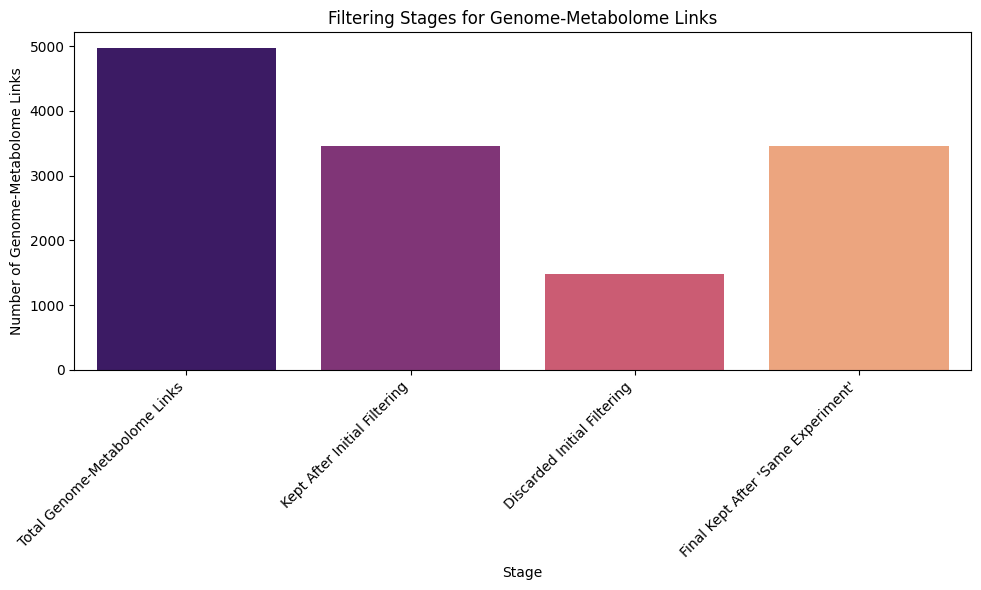

In [59]:
# Create a figure summarizing genome-metabolome filtering
# Data from previous cell outputs for genome-metabolome filtering
total_gm_links = 4966 # From output of cell 61591229
kept_gm_pairs_initial = 3454 # From output of cell 61591229
discarded_gm_pairs_initial = 1488 # From output of cell 61591229
kept_gm_pairs_final = 3454 # From output of cell fbabf6ba

# Construct DataFrame for genome filtering summary
genome_filtering_data = {
    "Stage": [
        "Total Genome-Metabolome Links",
        "Kept After Initial Filtering",
        "Discarded Initial Filtering",
        "Final Kept After 'Same Experiment'"
    ],
    "Count": [
        total_gm_links,
        kept_gm_pairs_initial,
        discarded_gm_pairs_initial,
        kept_gm_pairs_final
    ]
}
genome_filtering_df = pd.DataFrame(genome_filtering_data)

plt.close('all') # Close previous figure
print("\n--- Genome-Metabolome Link Filtering Summary ---")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x="Stage", y="Count", data=genome_filtering_df, palette="magma", ax=ax)
ax.set_ylabel("Number of Genome-Metabolome Links")
ax.set_title("Filtering Stages for Genome-Metabolome Links")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Downloading Paired Data Files

In [ ]:
# Install necessary libraries
!pip install biopython requests tqdm

In [ ]:
import pandas as pd
import os
from urllib.parse import urlparse
import shutil
from tqdm.notebook import tqdm
import socket

# Set a global timeout for socket operations to prevent indefinite hangs
socket.setdefaulttimeout(10)

# Define the directory for metabolome files
metabolome_dir = "downloaded_metabolomes"
os.makedirs(metabolome_dir, exist_ok=True)

# Function to download file using wget, which is generally more robust for varied URL types
def download_file_wget(url, local_path):
    try:
        # Special handling for MassIVE FTP URLs to convert them to HTTP download links
        if "massive.ucsd.edu" in url or "massive-ftp.ucsd.edu" in url:
            parsed_path = urlparse(url).path
            relative_path = parsed_path.lstrip('/')
            download_url = f"https://massive.ucsd.edu{relative_path}"
        else:
            download_url = url

        # Use wget with -q for quiet output and -O to specify the output file path
        cmd = f'wget -q -O "{local_path}" "{download_url}"'
        exit_code = os.system(cmd)

        # Check if the file was downloaded successfully and is not empty
        if exit_code == 0 and os.path.exists(local_path) and os.path.getsize(local_path) > 0:
            return True
        else:
            # Clean up any leftover partial files if download failed
            if os.path.exists(local_path):
                os.remove(local_path)
            return False

    except Exception as e:
        print(f"An error occurred executing wget for {url}: {e}")
        return False

# Filter for pairs where both genome and metabolome are identified as downloadable
# 'downloadability_df' is assumed to be available from previous steps
downloadable_pairs_for_metabolome_download = downloadability_df[downloadability_df['both_downloadable'] == True].copy()

print(f"Attempting to download metabolome files for {len(downloadable_pairs_for_metabolome_download)} pairs.")

# List to store metabolome download results temporarily
metabolome_download_summary = []

# Iterate through each pair to download metabolomes
for idx, row in tqdm(downloadable_pairs_for_metabolome_download.iterrows(), total=len(downloadable_pairs_for_metabolome_download), desc="Downloading metabolomes"):
    genome_label = row['genome_label']
    raw_metabolome_url = str(row['metabolomics_file_path']).strip()
    metabolome_download_status = "N/A"
    metabolome_local_path = None

    if row['has_metabolome_download'] and pd.notna(raw_metabolome_url) and raw_metabolome_url != 'nan':
        # Derive the filename from the URL
        url_path = urlparse(raw_metabolome_url).path
        metabolome_filename = os.path.basename(url_path)

        # Fallback if filename extraction is unsuccessful
        if not metabolome_filename:
            metabolome_filename = f"metabolome_{idx}.mzXML" # Assign a default name

        metabolome_local_path = os.path.join(metabolome_dir, metabolome_filename)

        if download_file_wget(raw_metabolome_url, metabolome_local_path):
            metabolome_download_status = "Downloaded"
        else:
            metabolome_download_status = "Failed"
    else:
        metabolome_download_status = "Not_Applicable"

    metabolome_download_summary.append({
        'genome_label': genome_label,
        'metabolomics_file_path': raw_metabolome_url,
        'genome_accession_value': row['genome_accession_value'],
        'genome_accession_type': row['genome_accession_type'],
        'metabolome_download_status': metabolome_download_status,
        'metabolome_local_path': metabolome_local_path if metabolome_download_status == "Downloaded" else None,
        # Initialize genome status for the next step
        'genome_download_status': "Pending",
        'genome_local_path': None
    })

# Convert to DataFrame and save to CSV so the next cell can load it
metabolome_summary_df = pd.DataFrame(metabolome_download_summary)
metabolome_summary_df.to_csv("podp_metabolome_download_temp_summary.csv", index=False)

print(f"\nCompleted metabolome downloads. Summary saved to podp_metabolome_download_temp_summary.csv")
print(f"Metabolomes Downloaded: {metabolome_summary_df['metabolome_download_status'].eq('Downloaded').sum()}")

Attempting to download metabolome files for 1364 pairs.



Completed metabolome downloads. Summary saved to podp_metabolome_download_temp_summary.csv
Metabolomes Downloaded: 0


In [ ]:
import pandas as pd
import os
from Bio import Entrez
from Bio import SeqIO # Included for completeness, not directly used in download_genome_ncbi
from tqdm.notebook import tqdm
import socket

# Ensure socket timeout is set, even if this cell is run independently
socket.setdefaulttimeout(10)

# Entrez credentials (replace with your actual email and API key)
Entrez.email = "rosalieg.wang@utoronto.ca" # Placeholder
Entrez.api_key = "977362a48f54e6e9731f2cdd333af47d0308" # Placeholder

# Define the directory for genome files
genome_dir = "downloaded_genomes"
os.makedirs(genome_dir, exist_ok=True)

# Function to download genome from NCBI in GenBank (.gbk) format only
def download_genome_ncbi(accession_id, local_path, db="nucleotide", rettype="gb", retmode="text"):
    try:
        handle = Entrez.efetch(db=db, id=accession_id, rettype=rettype, retmode=retmode)
        data = handle.read()
        handle.close()
        with open(local_path, "w") as f:
            f.write(data)
        return True
    except Exception as e:
        print(f"Error downloading NCBI genome {accession_id}: {e}")
        return False

# Load the metabolome download summary generated by the previous cell
download_summary_df = pd.read_csv("podp_metabolome_download_temp_summary.csv")

print(f"\nAttempting to download genome files for metabolomes that were successfully downloaded.")

# Iterate through the DataFrame to download genomes conditionally
for idx, row in tqdm(download_summary_df.iterrows(), total=len(download_summary_df), desc="Downloading genomes and final processing"):
    # Only attempt genome download if the corresponding metabolome was downloaded successfully
    if row['metabolome_download_status'] == "Downloaded":
        genome_accession_type = row['genome_accession_type']
        genome_accession_value = row['genome_accession_value']

        if pd.notna(genome_accession_value):
            # As requested, only download .gbk files (rettype="gb")
            genome_filename = f"{genome_accession_value}.gbk"
            genome_local_path = os.path.join(genome_dir, genome_filename)

            # Check for supported public accession types for NCBI Entrez download
            if genome_accession_type in ['GenBank_ID', 'RefSeq_ID', 'ENA_ID', 'JGI_Genome_ID']:
                if download_genome_ncbi(genome_accession_value, genome_local_path, rettype="gb", retmode="text"):
                    download_summary_df.loc[idx, 'genome_download_status'] = "Downloaded"
                    download_summary_df.loc[idx, 'genome_local_path'] = genome_local_path
                else:
                    download_summary_df.loc[idx, 'genome_download_status'] = "Failed_NCBI_Entrez"
            else:
                download_summary_df.loc[idx, 'genome_download_status'] = "Complex_API_Auth_Needed" # JGI or other non-NCBI IDs
        else:
            download_summary_df.loc[idx, 'genome_download_status'] = "No_Accession_Info"
    else:
        # If metabolome download failed or was not applicable, skip genome download
        download_summary_df.loc[idx, 'genome_download_status'] = "Skipped_Metabolome_Failed"


print("\n--- Download Summary Before Cleanup ---")
print(f"Total pairs processed: {len(download_summary_df)}")
print(f"Genomes Downloaded: {download_summary_df['genome_download_status'].eq('Downloaded').sum()}")
print(f"Metabolomes Downloaded: {download_summary_df['metabolome_download_status'].eq('Downloaded').sum()}")
print(f"Pairs with both Downloaded: {download_summary_df[(download_summary_df['genome_download_status'] == 'Downloaded') & (download_summary_df['metabolome_download_status'] == 'Downloaded')].shape[0]}")

# Save the initial summary to a CSV
output_download_summary_csv = "podp_download_test_summary_initial.csv"
download_summary_df.to_csv(output_download_summary_csv, index=False)
print(f"\nInitial download results saved to {output_download_summary_csv}")

# --- Post-processing Cleanup: Delete metabolomes if genome download failed ---
print("\n--- Cleaning up metabolome files where genome download was not successful ---")
metabolomes_deleted_count = 0
for idx, row in download_summary_df.iterrows():
    # Condition for deletion: metabolome was downloaded, but its paired genome was NOT successfully downloaded
    if row['metabolome_download_status'] == "Downloaded" and row['genome_download_status'] != "Downloaded":
        metabolome_file_to_delete = row['metabolome_local_path']
        if metabolome_file_to_delete and os.path.exists(metabolome_file_to_delete):
            try:
                os.remove(metabolome_file_to_delete)
                metabolomes_deleted_count += 1
                # Update the status in the DataFrame to reflect deletion
                download_summary_df.loc[idx, 'metabolome_download_status'] = 'Deleted_Genome_Failed'
                download_summary_df.loc[idx, 'metabolome_local_path'] = None # Clear local path as file is removed
            except OSError as e:
                print(f"Error deleting metabolome {metabolome_file_to_delete}: {e}")

print(f"Cleaned up {metabolomes_deleted_count} metabolome files.")

print("\n--- Final Download Summary After Cleanup ---")
print(f"Total pairs processed: {len(download_summary_df)}")
print(f"Genomes Downloaded: {download_summary_df['genome_download_status'].eq('Downloaded').sum()}")
print(f"Metabolomes Downloaded (and kept): {download_summary_df['metabolome_download_status'].eq('Downloaded').sum()}")
print(f"Pairs with both Downloaded (and kept): {download_summary_df[(download_summary_df['genome_download_status'] == 'Downloaded') & (download_summary_df['metabolome_download_status'] == 'Downloaded')].shape[0]}")

# Save the final summary to a new CSV
output_download_summary_csv_final = "podp_download_test_summary_final.csv"
download_summary_df.to_csv(output_download_summary_csv_final, index=False)
print(f"\nFinal download results saved to {output_download_summary_csv_final}")

display(download_summary_df.head())

# PoDP EDA

This notebook section explores the **Paired omics Data Platform (PoDP)** project records found in `PoDP/*.json`. Each JSON file is one submitted project that links a microbial **genome/metagenome** collection to a **GNPS/MassIVE metabolomics** dataset, and (optionally) documents specific **biosynthetic gene cluster (BGC) ↔ MS2 spectrum** links.

Questions this notebook answers:

1. How many project records are there, and what does one look like?
2. How many linked genomics ↔ metabolomics *pairs* exist (`genome_metabolome_links`)?
3. How many BGC↔MS2 links exist, and how many are backed by *verified* experimental evidence?
4. What other labels are already present in the data (genome type, extraction method, instrumentation, ionization, medium, institution, ...), and how can we aggregate the messy free-text versions of these into meaningful categories?

## 1. Load all project records

Each filename is `{project_uuid}.{version}.json`. We load every record into memory as a list of dicts, keeping the source filename for traceability.

In [40]:
projects = []
for fp_str in json_files:
    fp = Path(fp_str) # Convert string path to Path object
    with open(fp_str) as fh:
        d = json.load(fh)
    d["_source_file"] = fp.name
    d["_project_id"] = fp.stem.rsplit(".", 1)[0]  # uuid without the trailing version
    projects.append(d)

print(f"Loaded {len(projects)} project records")
print("Top-level keys seen across records:")
key_counts = Counter()
for p in projects:
    key_counts.update(p.keys())
for k, v in key_counts.most_common():
    print(f"  {k:28s} present in {v}/{len(projects)} records")

Loaded 76 project records
Top-level keys seen across records:
  version                      present in 76/76 records
  personal                     present in 76/76 records
  metabolomics                 present in 76/76 records
  experimental                 present in 76/76 records
  genomes                      present in 76/76 records
  genome_metabolome_links      present in 76/76 records
  proteomes                    present in 76/76 records
  _source_file                 present in 76/76 records
  _project_id                  present in 76/76 records
  BGC_MS2_links                present in 41/76 records


In [41]:
import textwrap
sample = projects[0]
print(sample["_source_file"])
print(textwrap.shorten(json.dumps(sample, indent=2), width=1500, placeholder=" ...[truncated]"))

acb6013a-bd1b-4216-a2a3-cf52da7b7084.1.json
{ "version": "3", "personal": { "submitter_name": "Kelly Weldon", "submitter_orcid": "https://orcid.org/0000-0003-1064-8153", "submitter_email": "kcweldon@eng.ucsd.edu", "PI_name": "Pieter C. Dorrestein", "PI_institution": "University of California, San Diego", "PI_email": "pdorrestein@health.ucsd.edu" }, "metabolomics": { "project": { "GNPSMassIVE_ID": "MSV000083302", "MaSSIVE_URL": "https://massive.ucsd.edu/ProteoSAFe/dataset.jsp?task=ef195e6569004a14a47560f7619e8591", "molecular_network": "6379dfdb0f7d4c31b75afd14c8f36778" } }, "experimental": { "sample_preparation": [ { "medium_details": { "medium_type": "metagenome", "metagenomic_environment": "https://bioportal.bioontology.org/ontologies/MEO/?p=classes&conceptid=http%3A%2F%2Fpurl.jp%2Fbio%2F11%2Fmeo%2FMEO_0000395", "metagenomic_sample_description": "Mus musculus fecal pellet" }, "growth_parameters": {}, "aeration": {}, "sample_preparation_method": "metagenomic_mouse_fecal" } ], "extract

## 2. Linked genomics ↔ metabolomics pairs

Each project's `genome_metabolome_links` list is the literal pairing of a `genome_label` (a genome/metagenome in the `genomes` block) with a `metabolomics_file` (a raw MS file inside the project's GNPS/MassIVE dataset). Each entry **is** one paired genomics–metabolomics data point.

In [42]:
gm_link_rows = []
for p in projects:
    for link in p.get("genome_metabolome_links", []) or []:
        row = dict(link)
        row["_project_id"] = p["_project_id"]
        row["_massive_id"] = p.get("metabolomics", {}).get("project", {}).get("GNPSMassIVE_ID")
        gm_link_rows.append(row)

gm_links = pd.DataFrame(gm_link_rows)
print(f"Total genomics<->metabolomics pairs (genome_metabolome_links rows): {len(gm_links)}")
print(f"Projects contributing at least one pair: {gm_links['_project_id'].nunique()} / {len(projects)}")
gm_links.head()

Total genomics<->metabolomics pairs (genome_metabolome_links rows): 4966
Projects contributing at least one pair: 76 / 76


,genome_label,metabolomics_file,sample_preparation_label,extraction_method_label,instrumentation_method_label,_project_id,_massive_id,proteome_label
0,ERS4356233,ftp://massive.ucsd.edu/MSV000083302/peak/mzxml...,metagenomic_mouse_fecal,SeedGrant_Extraction,Seed Grant TOF,acb6013a-bd1b-4216-a2a3-cf52da7b7084,MSV000083302,NaN
1,ERS4356234,ftp://massive.ucsd.edu/MSV000083302/peak/mzxml...,metagenomic_mouse_fecal,SeedGrant_Extraction,Seed Grant TOF,acb6013a-bd1b-4216-a2a3-cf52da7b7084,MSV000083302,NaN
2,ERS4356235,ftp://massive.ucsd.edu/MSV000083302/peak/mzxml...,metagenomic_mouse_fecal,SeedGrant_Extraction,Seed Grant TOF,acb6013a-bd1b-4216-a2a3-cf52da7b7084,MSV000083302,NaN
3,ERS4356236,ftp://massive.ucsd.edu/MSV000083302/peak/mzxml...,metagenomic_mouse_fecal,SeedGrant_Extraction,Seed Grant TOF,acb6013a-bd1b-4216-a2a3-cf52da7b7084,MSV000083302,NaN
4,ERS4356237,ftp://massive.ucsd.edu/MSV000083302/peak/mzxml...,metagenomic_mouse_fecal,SeedGrant_Extraction,Seed Grant TOF,acb6013a-bd1b-4216-a2a3-cf52da7b7084,MSV000083302,NaN


count     76.000000
mean      65.342105
std      131.027280
min        1.000000
25%        2.750000
50%       10.000000
75%       44.000000
max      620.000000
dtype: float64


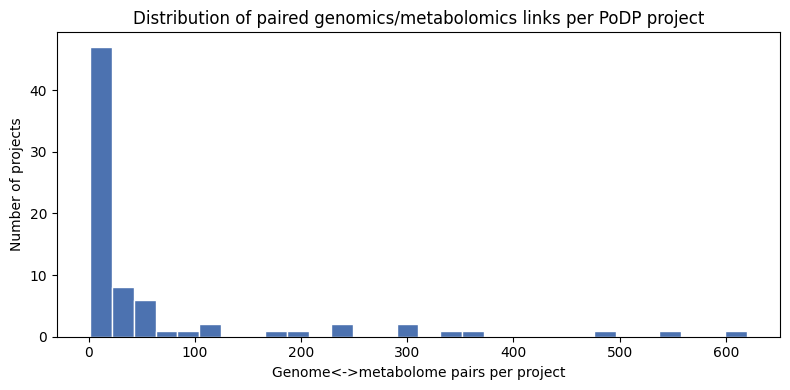

In [43]:
pairs_per_project = gm_links.groupby("_project_id").size().sort_values(ascending=False)
print(pairs_per_project.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pairs_per_project, bins=30, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Genome<->metabolome pairs per project")
ax.set_ylabel("Number of projects")
ax.set_title("Distribution of paired genomics/metabolomics links per PoDP project")
plt.tight_layout()
plt.show()

## 3. BGC ↔ MS2 spectral links

A smaller subset of projects additionally document explicit **biosynthetic gene cluster (BGC) to MS2 spectrum** links in `BGC_MS2_links`. Each entry records a `link` type, a free-text `known_link` description, an optional `MIBiG_number`, the `MS2_URL`/`MS2_scan` pointing at the actual supporting spectrum, and a `verification` list describing the strength of evidence behind the link.

We treat a BGC-MS2 link as having a **verified spectral link** when it actually points at a spectrum (`MS2_URL` and/or `MS2_scan` present) *and* carries at least one non-empty `verification` entry.

In [44]:
bgc_rows = []
for p in projects:
    for link in p.get("BGC_MS2_links", []) or []:
        row = dict(link)
        row["_project_id"] = p["_project_id"]
        verification = row.get("verification", [])
        if isinstance(verification, str):
            verification = [verification]
        row["verification"] = verification
        row["mibig_number"] = (row.get("BGC_ID") or {}).get("MIBiG_number")
        row["has_ms2_pointer"] = bool(row.get("MS2_URL") or row.get("MS2_scan"))
        row["has_verification"] = bool(verification)
        row["verified_ms2_link"] = row["has_ms2_pointer"] and row["has_verification"]
        bgc_rows.append(row)

bgc_links = pd.DataFrame(bgc_rows)
n_projects_with_bgc = bgc_links["_project_id"].nunique() if len(bgc_links) else 0

print(f"Total BGC_MS2_links entries: {len(bgc_links)}")
print(f"Projects with at least one BGC_MS2_links entry: {n_projects_with_bgc} / {len(projects)}")
print(f"BGC entries with a verified MS2 spectral link: {int(bgc_links['verified_ms2_link'].sum())}")
print(f"BGC entries with a MIBiG accession: {bgc_links['mibig_number'].notna().sum()}")
bgc_links[["_project_id", "link", "mibig_number", "has_ms2_pointer", "has_verification", "verified_ms2_link"]].head(10)

Total BGC_MS2_links entries: 115
Projects with at least one BGC_MS2_links entry: 33 / 76
BGC entries with a verified MS2 spectral link: 67
BGC entries with a MIBiG accession: 82


,_project_id,link,mibig_number,has_ms2_pointer,has_verification,verified_ms2_link
0,6ad1d8ed-40e4-4417-9ca2-c9274efb5f9c,single molecule,BGC0000845,True,True,True
1,6ad1d8ed-40e4-4417-9ca2-c9274efb5f9c,single molecule,BGC0000319,True,True,True
2,6ad1d8ed-40e4-4417-9ca2-c9274efb5f9c,single molecule,BGC0000880,True,True,True
3,6ad1d8ed-40e4-4417-9ca2-c9274efb5f9c,single molecule,BGC0000880,True,True,True
4,6ad1d8ed-40e4-4417-9ca2-c9274efb5f9c,single molecule,BGC0000880,True,True,True
5,6ad1d8ed-40e4-4417-9ca2-c9274efb5f9c,single molecule,BGC0001310,True,True,True
6,e26c5e21-e3de-4448-9623-a085cb71eca6,GNPS molecular family,None,False,True,False
7,e26c5e21-e3de-4448-9623-a085cb71eca6,GNPS molecular family,BGC0000964,False,True,False
8,e26c5e21-e3de-4448-9623-a085cb71eca6,GNPS molecular family,BGC0001102,False,True,False
9,e26c5e21-e3de-4448-9623-a085cb71eca6,GNPS molecular family,BGC0000961,False,True,False


In [45]:
# Breakdown of the verification evidence categories (a link can carry multiple types of evidence)
verification_counts = Counter()
for v_list in bgc_links["verification"]:
    verification_counts.update(v_list)

verification_df = (
    pd.Series(verification_counts, name="count")
    .sort_values(ascending=False)
    .rename_axis("verification_type")
    .reset_index()
)
verification_df

,verification_type,count
0,Experimentally validated with NMR and/or detai...,93
1,Bioinformatically inferred through comparative...,55
2,"Experimentally validated with knockouts, heter...",39
3,Evidence as indicated in MIBiG,38


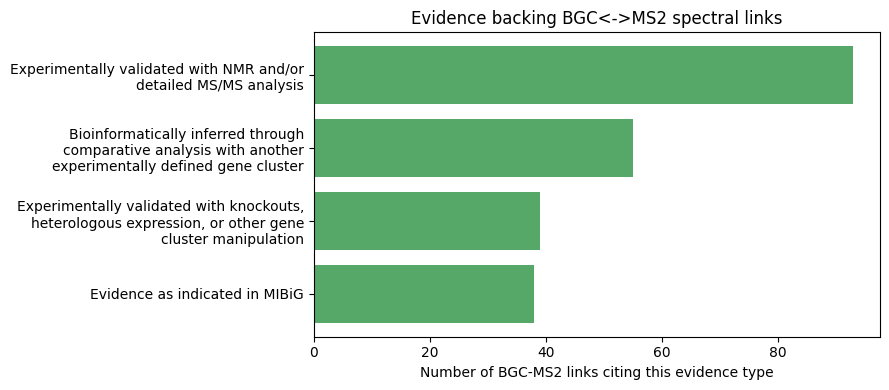

In [46]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(verification_df["verification_type"].str.wrap(45), verification_df["count"], color="#55A868")
ax.invert_yaxis()
ax.set_xlabel("Number of BGC-MS2 links citing this evidence type")
ax.set_title("Evidence backing BGC<->MS2 spectral links")
plt.tight_layout()
plt.show()

## 4. Other inherent labels, and aggregating them meaningfully

Beyond the pairing counts, every project record already carries a handful of categorical/free-text labels we can mine:

- **Genome type** (`genomes[].genome_ID.genome_type`): `genome`, `metagenome`, `metagenome-assembled genome` — already a clean controlled vocabulary.
- **Extraction method / instrumentation method / ionization type** (`experimental.*`): free text entered by submitters, so the same method appears under many spellings (e.g. `MeOH`, `Methanol`, `EtOAc`, `Ethyl acetate`, `TOF`, `ToF`, `QToF`). We normalize these with a small synonym map into meaningful buckets.
- **Medium type** (`solid` / `liquid` / `metagenome`) — already clean.
- **Submitting institution** (`personal.PI_institution`) — free text, also benefits from light normalization (e.g. "UCSD" vs "University of California San Diego" vs "University of California, San Diego").

In [47]:
# --- Genome type (already a clean label) ---
genome_rows = []
for p in projects:
    for g in p.get("genomes", []) or []:
        genome_rows.append({
            "_project_id": p["_project_id"],
            "genome_label": g.get("genome_label"),
            "genome_type": (g.get("genome_ID") or {}).get("genome_type"),
        })
genomes_df = pd.DataFrame(genome_rows)

genome_type_counts = genomes_df["genome_type"].value_counts()
print(f"Total genome/metagenome entries across all projects: {len(genomes_df)}")
genome_type_counts

Total genome/metagenome entries across all projects: 2634


,count
genome_type,
metagenome,1306
genome,1286
metagenome-assembled genome,42


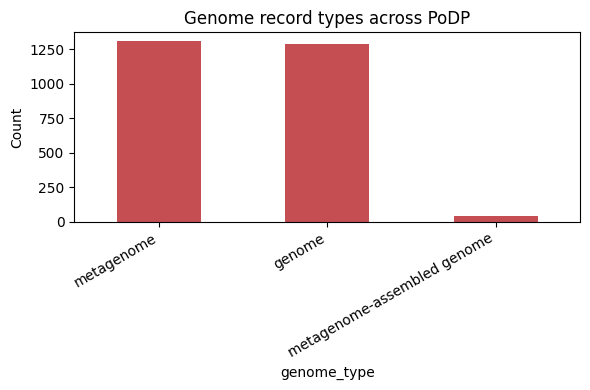

In [48]:
fig, ax = plt.subplots(figsize=(6, 4))
genome_type_counts.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("Count")
ax.set_title("Genome record types across PoDP")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [49]:
# --- Extraction method: normalize free text into meaningful buckets ---
extraction_method_map = {
    r"meoh|methanol": "Methanol",
    r"etoac|ethyl\s*acetate": "Ethyl acetate",
    r"buoh|butanol": "Butanol",
    r"dcm|dichloromethane": "Dichloromethane (DCM) mix",
    r"\bxad\b": "XAD resin",
    r"\bspe\b": "SPE",
    r"h2o|water": "Aqueous",
}

def normalize_label(raw, pattern_map, default="Other / unclassified"):
    if not raw:
        return default
    text = str(raw).lower()
    for pattern, bucket in pattern_map.items():
        if re.search(pattern, text):
            return bucket
    return default

extraction_rows = []
for p in projects:
    for m in (p.get("experimental", {}).get("extraction_methods") or []):
        raw = m.get("extraction_method")
        extraction_rows.append({
            "_project_id": p["_project_id"],
            "raw_label": raw,
            "extraction_bucket": normalize_label(raw, extraction_method_map),
        })
extraction_df = pd.DataFrame(extraction_rows)

print("Raw label -> normalized bucket (sample):")
display_cols = extraction_df.drop_duplicates("raw_label")[["raw_label", "extraction_bucket"]]
print(display_cols.to_string(index=False))
print()
extraction_bucket_counts = extraction_df["extraction_bucket"].value_counts()
extraction_bucket_counts

Raw label -> normalized bucket (sample):
                                   raw_label         extraction_bucket
                        SeedGrant_Extraction      Other / unclassified
                                   Oasis HLB      Other / unclassified
                                    Methanol                  Methanol
                                       EtOAc             Ethyl acetate
                                          EA      Other / unclassified
                                      EA+HAc      Other / unclassified
                                     SPE_C18      Other / unclassified
                                   EtAc_agar      Other / unclassified
                                          M1      Other / unclassified
                                         XAD                 XAD resin
                                     Butanol                   Butanol
                 Streptophenazine extraction      Other / unclassified
                Salinispora arenicol

,count
extraction_bucket,
Other / unclassified,46
Methanol,24
Ethyl acetate,18
Butanol,9
XAD resin,4
SPE,3
Dichloromethane (DCM) mix,2
Aqueous,1


In [50]:
# --- Instrumentation method: normalize TOF/QTOF/Orbitrap/IonTrap spelling variants ---
instrumentation_map = {
    r"qtof|q-tof|q\s*tof": "QTOF",
    r"\btof\b": "TOF",
    r"orbitrap": "Orbitrap",
    r"iontrap|ion trap": "Ion Trap",
    r"lc-ms|lcms": "LC-MS (unspecified)",
}

instrumentation_rows = []
for p in projects:
    for m in (p.get("experimental", {}).get("instrumentation_methods") or []):
        raw = m.get("instrumentation_method")
        instrumentation_rows.append({
            "_project_id": p["_project_id"],
            "raw_label": raw,
            "instrument_bucket": normalize_label(raw, instrumentation_map),
        })
instrumentation_df = pd.DataFrame(instrumentation_rows)
instrument_bucket_counts = instrumentation_df["instrument_bucket"].value_counts()
instrument_bucket_counts

,count
instrument_bucket,
Other / unclassified,37
TOF,14
QTOF,12
LC-MS (unspecified),12
Orbitrap,6
Ion Trap,2


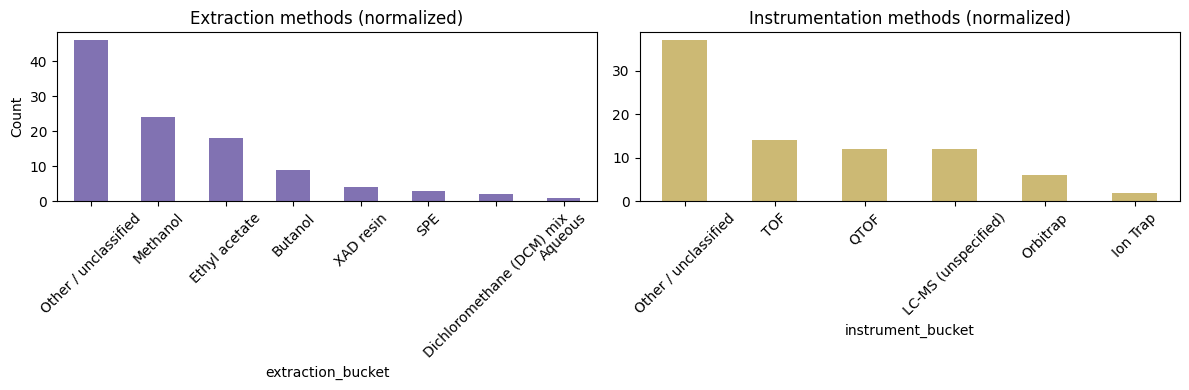

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
extraction_bucket_counts.plot(kind="bar", ax=axes[0], color="#8172B2")
axes[0].set_title("Extraction methods (normalized)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

instrument_bucket_counts.plot(kind="bar", ax=axes[1], color="#CCB974")
axes[1].set_title("Instrumentation methods (normalized)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [52]:
# --- Submitting institution: light normalization of near-duplicate names ---
institution_map = {
    r"university of california,?\s*san diego|\bucsd\b": "UC San Diego",
    r"scripps institution of oceanography": "Scripps Institution of Oceanography",
}

institution_rows = []
for p in projects:
    raw = p.get("personal", {}).get("PI_institution")
    institution_rows.append({
        "_project_id": p["_project_id"],
        "raw_label": raw,
        "institution_bucket": normalize_label(raw, institution_map, default=raw or "Unknown"),
    })
institution_df = pd.DataFrame(institution_rows)
institution_counts = institution_df["institution_bucket"].value_counts()
print(f"Unique raw institution strings: {institution_df['raw_label'].nunique()}")
print(f"Unique institutions after normalization: {institution_df['institution_bucket'].nunique()}")
institution_counts.head(10)

Unique raw institution strings: 46
Unique institutions after normalization: 41


,count
institution_bucket,
UC San Diego,19
Leiden University (Institute of Biology Leiden),4
Scripps Institution of Oceanography,3
Technische Universität Berlin,3
University of Wisconsin-Madison,3
ETH Zurich,3
University of Nottingham,3
Universidade de São Paulo,2
Memorial University of Newfoundland,2


## 5. Per-project summary table

A tidy, one-row-per-project rollup combining everything above — useful as a starting point for downstream filtering/joining (e.g. "give me every project with a verified BGC-MS2 link AND more than 20 paired samples").

In [53]:
summary_rows = []
for p in projects:
    pid = p["_project_id"]
    n_genomes = len(p.get("genomes", []) or [])
    n_pairs = len(p.get("genome_metabolome_links", []) or [])
    bgc_entries = p.get("BGC_MS2_links", []) or []
    n_bgc = len(bgc_entries)
    n_verified = sum(
        1 for link in bgc_entries
        if (link.get("MS2_URL") or link.get("MS2_scan"))
        and (link.get("verification") if isinstance(link.get("verification"), list) else [link.get("verification")]) not in ([], [None])
    )
    summary_rows.append({
        "project_id": pid,
        "massive_id": p.get("metabolomics", {}).get("project", {}).get("GNPSMassIVE_ID"),
        "PI_institution": p.get("personal", {}).get("PI_institution"),
        "n_genomes": n_genomes,
        "n_genome_metabolome_pairs": n_pairs,
        "n_BGC_MS2_links": n_bgc,
        "n_verified_BGC_MS2_links": n_verified,
    })

project_summary = pd.DataFrame(summary_rows).sort_values("n_genome_metabolome_pairs", ascending=False)
project_summary.reset_index(drop=True, inplace=True)
project_summary

,project_id,massive_id,PI_institution,n_genomes,n_genome_metabolome_pairs,n_BGC_MS2_links,n_verified_BGC_MS2_links
0,5e920f02-2ae7-4d58-a4b9-fc76740958cd,MSV000082045,"University of California, San Diego",303,620,0,0
1,cd327ceb-f92b-4cd3-a545-39d29c602b6b,MSV000082969,"University of California, San Diego",556,556,0,0
2,50f9540c-9c9c-44e6-956c-87eabc960d7b,MSV000080179,UCSD,481,481,0,0
3,297c364c-b154-4edd-a7d5-68decf9effa2,MSV000078836,University of Bonn,120,360,9,0
4,0ff7a302-49af-4130-a440-59e284d4d365,MSV000078839,University of Nottingham,39,351,5,0
...,...,...,...,...,...,...,...
71,d0f1add5-5b16-4f78-9b93-0d1d9c9bcb59,MSV000086050,"Scripps Institution of Oceanography, Universit...",1,1,1,0
72,b14413c8-329b-47b5-9a08-cbead882187e,MSV000085027,University of Wisconsin-Madison,1,1,0,0
73,577a750e-50ac-4866-8881-3ad018f4848e,MSV000085192,Universitz of Bonn,1,1,1,0
74,b4ae671a-c702-4150-b5db-240a8e28aa17,MSV000084989,Sungkyunkwan University,1,1,0,0


## 6. Headline answers

Recap of the specific questions asked at the top of the notebook.

In [54]:
total_pairs = len(gm_links)
total_bgc_ms2 = len(bgc_links)
total_verified = int(bgc_links["verified_ms2_link"].sum()) if len(bgc_links) else 0

print(f"Projects loaded:                                     {len(projects)}")
print(f"Total linked genomics<->metabolomics pairs:          {total_pairs}")
print(f"Total BGC_MS2_links entries:                          {total_bgc_ms2}")
print(f"BGC_MS2_links with a verified MS2 spectral link:      {total_verified}")
print(f"Projects with >=1 BGC_MS2_link:                       {n_projects_with_bgc}")

Projects loaded:                                     76
Total linked genomics<->metabolomics pairs:          4966
Total BGC_MS2_links entries:                          115
BGC_MS2_links with a verified MS2 spectral link:      67
Projects with >=1 BGC_MS2_link:                       33
